In [1]:
import tensorflow as tf 
import numpy as np
import matplotlib.pyplot as plt 
import tensorflow_datasets as tfds

In [84]:
dataset , dataset_info = tfds.load('malaria',with_info=True,as_supervised=True,split=['train[:80%]', 'train[80%:]']) # with_info is by  default false , as_supervised is true to get (image,label) tuple

In [85]:
dataset_info # Provide information about the dataset

tfds.core.DatasetInfo(
    name='malaria',
    full_name='malaria/1.0.0',
    description="""
    The Malaria dataset contains a total of 27,558 cell images with equal instances
    of parasitized and uninfected cells from the thin blood smear slide images of
    segmented cells.
    """,
    homepage='https://lhncbc.nlm.nih.gov/publication/pub9932',
    data_dir='C:\\Users\\HP\\tensorflow_datasets\\malaria\\1.0.0',
    file_format=tfrecord,
    download_size=337.08 MiB,
    dataset_size=317.62 MiB,
    features=FeaturesDict({
        'image': Image(shape=(None, None, 3), dtype=uint8),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=2),
    }),
    supervised_keys=('image', 'label'),
    disable_shuffling=False,
    nondeterministic_order=False,
    splits={
        'train': <SplitInfo num_examples=27558, num_shards=4>,
    },
    citation="""@article{rajaraman2018pre,
      title={Pre-trained convolutional neural networks as feature extractors toward
      improved mala

In [86]:
dataset

[<_PrefetchDataset element_spec=(TensorSpec(shape=(None, None, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>,
 <_PrefetchDataset element_spec=(TensorSpec(shape=(None, None, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>]

In [87]:
print(type(dataset))     # should show <class 'list'>
print(len(dataset))      # number of splits returned

for i, ds in enumerate(dataset):
    print(f"\n--- Split {i} ---")
    print("Type:", type(ds))
    print("Element spec:", ds.element_spec)


<class 'list'>
2

--- Split 0 ---
Type: <class 'tensorflow.python.data.ops.prefetch_op._PrefetchDataset'>
Element spec: (TensorSpec(shape=(None, None, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))

--- Split 1 ---
Type: <class 'tensorflow.python.data.ops.prefetch_op._PrefetchDataset'>
Element spec: (TensorSpec(shape=(None, None, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))


In [88]:
print(dataset_info.splits['train'].num_examples)   # total images
print("Train (80%):", int(0.8 * dataset_info.splits['train'].num_examples))
print("Test  (20%):", int(0.2 * dataset_info.splits['train'].num_examples))


27558
Train (80%): 22046
Test  (20%): 5511


In [89]:
def splits_dataset(dataset,TRAIN_RATIO,VAL_RATIO,TEST_RATIO):
  DATASET_SIZE = len(dataset)
  train_dataset = dataset.take(int(TRAIN_RATIO * DATASET_SIZE))
  val_test_dataset = dataset.skip(int(TRAIN_RATIO * DATASET_SIZE))
  val_dataset = val_test_dataset.take(int(VAL_RATIO * DATASET_SIZE))
  test_dataset = val_test_dataset.skip(int(VAL_RATIO * DATASET_SIZE))
  return train_dataset, val_dataset, test_dataset

In [90]:
TRAIN_RATIO = 0.8
VAL_RATIO = 0.1
TEST_RATIO = 0.1

train_dataset,test_dataset,val_dataset = splits_dataset(dataset[0],TRAIN_RATIO,VAL_RATIO,TEST_RATIO)

print(f"The len of the train dataset is :{len(train_dataset)}")
print(f"The len of the test dataset is :{len(test_dataset)}")
print(f"The len of the val dataset is :{len(val_dataset)}")


The len of the train dataset is :17636
The len of the test dataset is :2204
The len of the val dataset is :2206


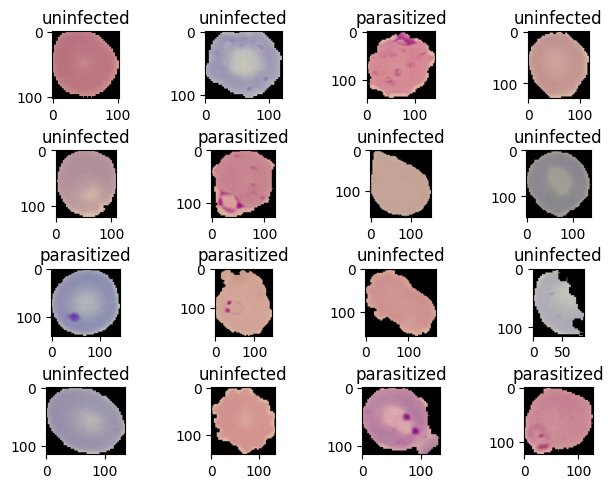

In [91]:
for i,(image,label) in enumerate(train_dataset.take(16)):
    ax = plt.subplot(4, 4, i + 1)
    ax.imshow(image)
    plt.title(dataset_info.features['label'].int2str(label))
plt.tight_layout(pad=0.4)   # pad controls spacing between images
plt.show()

#### Data Preprocessing

In [92]:
IM_SIZE = 224
def resizing(image,label):
  return tf.image.resize(image,(IM_SIZE,IM_SIZE))/255.0,label

In [93]:
train_dataset = train_dataset.map(resizing)

In [94]:
for image,label in train_dataset.take(1):
  print(image)

tf.Tensor(
[[[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 ...

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]], shape=(224, 224, 3), dtype=float32)


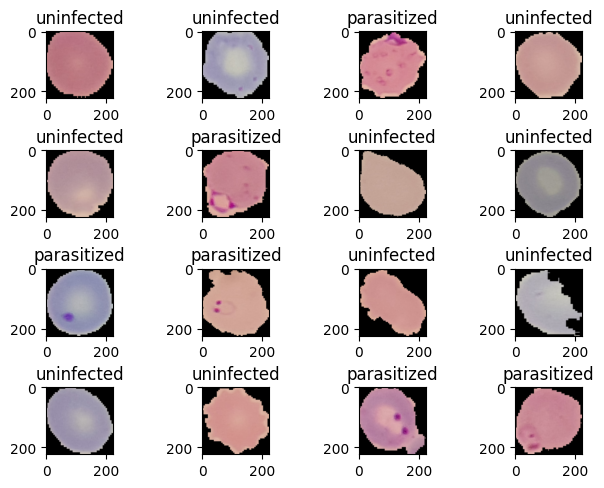

In [95]:
for i,(image,label) in enumerate(train_dataset.take(16)):
    ax = plt.subplot(4, 4, i + 1)
    ax.imshow(image)
    plt.title(dataset_info.features['label'].int2str(label))
plt.tight_layout(pad=0.4)   # pad controls spacing between images
plt.show()

In [ ]:
train_dataset = train_dataset.shuffle(buffer_size=8,reshuffle_each_iteration=True).batch(32).prefetch(tf.data.AUTOTUNE)